# Document Extraction Evaluation Toolkit

This notebook demonstrates how to evaluate your document extraction model using the shared evaluation metrics.

**Workflow:**
1. Load ground truth data
2. Run your model (placeholder — you provide this)
3. Score individual fields
4. Build full evaluation results
5. Generate analytics, reports, and visualizations

In [1]:
# Cell 1: Imports and setup
import sys
from pathlib import Path

# Ensure project root is on the path
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from common.batch_analytics import BatchAnalytics
from common.batch_reporting import BatchReporter
from common.batch_visualizations import BatchVisualizer
from common.config import get_document_type_fields
from common.evaluation_metrics import (
    calculate_field_accuracy_with_method,
    load_ground_truth,
)

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
# Cell 2: Load ground truth
GROUND_TRUTH_PATH = "evaluation_data/synthetic/ground_truth_synthetic.csv"
IMAGE_DIR = Path("evaluation_data/synthetic")

ground_truth = load_ground_truth(GROUND_TRUTH_PATH, show_sample=True)

# List available images
image_files = sorted(IMAGE_DIR.glob("*.png"))
print(f"\nFound {len(image_files)} images:")
for img in image_files:
    print(f"  - {img.name}")

📊 Ground truth CSV loaded with 9 rows and 20 columns
📋 Available columns: ['image_file', 'DOCUMENT_TYPE', 'BUSINESS_ABN', 'BUSINESS_ADDRESS', 'GST_AMOUNT', 'INVOICE_DATE', 'IS_GST_INCLUDED', 'LINE_ITEM_DESCRIPTIONS', 'LINE_ITEM_QUANTITIES', 'LINE_ITEM_PRICES', 'LINE_ITEM_TOTAL_PRICES', 'PAYER_ADDRESS', 'PAYER_NAME', 'STATEMENT_DATE_RANGE', 'SUPPLIER_NAME', 'TOTAL_AMOUNT', 'TRANSACTION_AMOUNTS_PAID', 'TRANSACTION_DATES', 'TRANSACTION_AMOUNTS_RECEIVED', 'ACCOUNT_BALANCE']
✅ Using 'image_file' as image identifier column
📄 Sample ground truth data:
   image_file DOCUMENT_TYPE   BUSINESS_ABN                  BUSINESS_ADDRESS GST_AMOUNT INVOICE_DATE IS_GST_INCLUDED                                                                          LINE_ITEM_DESCRIPTIONS  LINE_ITEM_QUANTITIES                               LINE_ITEM_PRICES                         LINE_ITEM_TOTAL_PRICES                      PAYER_ADDRESS    PAYER_NAME STATEMENT_DATE_RANGE SUPPLIER_NAME TOTAL_AMOUNT TRANSACTION_AMOUNTS_PAI

## Run Your Model Here

Replace the placeholder below with your own model inference code.

Your model should return a dictionary of extracted fields for each image.

### Expected output format

```python
extracted_data = {
    "DOCUMENT_TYPE": "RECEIPT",
    "BUSINESS_ABN": "06 082 698 025",
    "SUPPLIER_NAME": "Liberty Oil",
    "BUSINESS_ADDRESS": "481 Bourke Street Perth WA 6000",
    "PAYER_NAME": "Robert Taylor",
    "PAYER_ADDRESS": "243 Adelaide Street Perth WA 6000",
    "INVOICE_DATE": "05/08/2025",
    "LINE_ITEM_DESCRIPTIONS": "Car Wash | Coffee Large | Unleaded Petrol",
    "LINE_ITEM_QUANTITIES": "3 | 1 | 1",
    "LINE_ITEM_PRICES": "$15.00 | $4.50 | $1.65",
    "LINE_ITEM_TOTAL_PRICES": "$45.00 | $4.50 | $1.65",
    "IS_GST_INCLUDED": "true",
    "GST_AMOUNT": "$8.62",
    "TOTAL_AMOUNT": "$94.87",
}
```

Fields not found should be set to `"NOT_FOUND"`.

List fields use pipe `|` as delimiter.

In [3]:
# Cell 3: Placeholder — run your model on all images
#
# Replace this with your actual model inference.
# For demonstration, we use the ground truth as "perfect" predictions.

import time


def run_your_model(image_path: Path) -> dict:
    """Replace this with your model inference."""
    # PLACEHOLDER: Returns ground truth as if the model predicted perfectly.
    # In practice, load the image and run your model here.
    image_name = image_path.name
    if image_name in ground_truth:
        gt = ground_truth[image_name]
        return {k: v for k, v in gt.items() if k != "image_file"}
    return {}


# Run model on all images and collect results
batch_results = []
processing_times = []

for img_path in image_files:
    start = time.time()
    extracted_data = run_your_model(img_path)
    print(f"{extracted_data=}")
    elapsed = time.time() - start
    processing_times.append(elapsed)

    batch_results.append({
        "image_name": img_path.name,
        "document_type": extracted_data.get("DOCUMENT_TYPE", "unknown").lower(),
        "processing_time": elapsed,
        "prompt_used": "your_prompt",
        "extracted_data": extracted_data,
    })

print(f"Processed {len(batch_results)} images.")

extracted_data={'DOCUMENT_TYPE': 'BANK_STATEMENT', 'BUSINESS_ABN': 'NOT_FOUND', 'BUSINESS_ADDRESS': 'NOT_FOUND', 'GST_AMOUNT': 'NOT_FOUND', 'INVOICE_DATE': 'NOT_FOUND', 'IS_GST_INCLUDED': 'NOT_FOUND', 'LINE_ITEM_DESCRIPTIONS': 'GROCERY MARKET SUBURB NSW AUS Card xx5678 | DEPARTMENT STORE SHOPPING DIST NS AUS Card xx5678 | CAFE CENTRAL T 54321F SUBURB AUS Card xx5678 | CAFE CENTRAL T 54321F SUBURB AUS Card xx5678 | ONLINE RETAILER.COM SYDNEY AU AUS Card xx5678 | SERVICE STATION SUBURB NS AUS Card xx5678 | SERVICE STATION SUBURB NS AUS Card xx5678 | ONLINE SUBSCRIPTION SYDNEY AU AUS Card xx5678 | ONLINE SUBSCRIPTION SYDNEY AU AUS Card xx5678 | ELECTRONICS 9876 SUBURB NSW AUS Card xx5678 | PHARMACY SERVICES MELBOURNE AUS Card xx5678 | BOOKSTORE 2345 SYDNEY AUS Card xx5678', 'LINE_ITEM_QUANTITIES': 'NOT_FOUND', 'LINE_ITEM_PRICES': 'NOT_FOUND', 'LINE_ITEM_TOTAL_PRICES': 'NOT_FOUND', 'PAYER_ADDRESS': 'NOT_FOUND', 'PAYER_NAME': 'NOT_FOUND', 'STATEMENT_DATE_RANGE': '03 Jun 2023 - 14 Jun 2023',

In [4]:
# Cell 4: Score a single field (quick demo)

# Example: compare one field from one image
sample_result = batch_results[0]
sample_gt = ground_truth[sample_result["image_name"]]

field = "TOTAL_AMOUNT"
extracted_val = sample_result["extracted_data"].get(field, "NOT_FOUND")
gt_val = sample_gt.get(field, "NOT_FOUND")

print(f"Image: {sample_result['image_name']}")
print(f"Field: {field}")
print(f"Extracted: {extracted_val}")
print(f"Ground Truth: {gt_val}")
print()

# Score with different methods
for method in ["order_aware_f1", "f1", "kieval"]:
    result = calculate_field_accuracy_with_method(
        extracted_val, gt_val, field, method=method, debug=False
    )
    print(f"{method:>20s}: F1={result['f1_score']:.2%}")

Image: cba_amount_balance.png
Field: TOTAL_AMOUNT
Extracted: NOT_FOUND
Ground Truth: NOT_FOUND

      order_aware_f1: F1=100.00%
                  f1: F1=100.00%
              kieval: F1=100.00%


In [5]:
# Cell 5: Full evaluation — score all fields for all images

for result in batch_results:
    image_name = result["image_name"]
    extracted = result["extracted_data"]
    gt = ground_truth.get(image_name, {})

    doc_type = extracted.get("DOCUMENT_TYPE", "invoice").lower()
    # Map detected type to schema type
    type_map = {
        "receipt": "receipt", "invoice": "invoice",
        "tax invoice": "invoice", "bank_statement": "bank_statement",
        "bank statement": "bank_statement", "statement": "bank_statement",
    }
    schema_type = type_map.get(doc_type, "invoice")
    fields = get_document_type_fields(schema_type)

    field_accuracies = {}
    for field in fields:
        ext_val = extracted.get(field, "NOT_FOUND")
        gt_val = gt.get(field, "NOT_FOUND")
        metrics = calculate_field_accuracy_with_method(
            ext_val, gt_val, field, method="order_aware_f1"
        )
        field_accuracies[field] = {"accuracy": metrics["f1_score"]}

    overall = sum(d["accuracy"] for d in field_accuracies.values()) / len(field_accuracies) if field_accuracies else 0.0
    matched = sum(1 for d in field_accuracies.values() if d["accuracy"] >= 0.5)

    result["evaluation"] = {
        "overall_accuracy": overall,
        "fields_extracted": len(field_accuracies),
        "fields_matched": matched,
        "total_fields": len(fields),
        "field_accuracies": field_accuracies,
    }

    print(f"{image_name}: {overall:.1%} ({matched}/{len(fields)} fields matched)")

# Overall batch accuracy
avg_acc = sum(r["evaluation"]["overall_accuracy"] for r in batch_results) / len(batch_results)
print(f"\nBatch Average: {avg_acc:.1%}")

cba_amount_balance.png: 100.0% (5/5 fields matched)
cba_debit_credit.png: 100.0% (5/5 fields matched)
cba_highligted.png: 100.0% (5/5 fields matched)
image_001.png: 100.0% (14/14 fields matched)
image_002.png: 100.0% (14/14 fields matched)
image_004.png: 100.0% (14/14 fields matched)
image_005.png: 100.0% (14/14 fields matched)
image_006.png: 100.0% (14/14 fields matched)
image_007.png: 100.0% (14/14 fields matched)

Batch Average: 100.0%


In [6]:
# Cell 6: Analytics — DataFrames and CSV export

analytics = BatchAnalytics(batch_results, processing_times)

df_results = analytics.create_results_dataframe()
df_summary = analytics.create_summary_statistics(df_results)
df_doctype = analytics.create_doctype_statistics(df_results)
df_fields = analytics.create_field_statistics(df_results)

print("=== Summary Statistics ===")
display(df_summary)

print("\n=== Document Type Statistics ===")
display(df_doctype)

if df_fields is not None:
    print("\n=== Field-Level Statistics ===")
    display(df_fields)

# Optional: save to CSV
# output_dir = Path("output")
# output_dir.mkdir(exist_ok=True)
# analytics.save_all_dataframes(output_dir, "my_model_run")

=== Summary Statistics ===


,Value
Total Images,9.000000e+00
Successful Extractions,9.000000e+00
Failed Extractions,0.000000e+00
Average Accuracy (%),1.000000e+02
Median Accuracy (%),1.000000e+02
Min Accuracy (%),1.000000e+02
Max Accuracy (%),1.000000e+02
Average Processing Time (s),1.841121e-05
Total Processing Time (s),1.657009e-04
Throughput (images/min),3.258884e+06



=== Document Type Statistics ===


,overall_accuracy_mean,overall_accuracy_median,overall_accuracy_std,overall_accuracy_min,overall_accuracy_max,processing_time_mean,processing_time_median,count
document_type,,,,,,,,
bank_statement,100.0,100.0,0.0,100.0,100.0,0.0,0.0,3
invoice,100.0,100.0,0.0,100.0,100.0,0.0,0.0,3
receipt,100.0,100.0,0.0,100.0,100.0,0.0,0.0,3



=== Field-Level Statistics ===


,Average Accuracy (%),Min Accuracy (%),Max Accuracy (%),Std Dev (%)
DOCUMENT_TYPE,100.0,100.0,100.0,0.0
PAYER_ADDRESS,100.0,100.0,100.0,0.0
GST_AMOUNT,100.0,100.0,100.0,0.0
IS_GST_INCLUDED,100.0,100.0,100.0,0.0
LINE_ITEM_TOTAL_PRICES,100.0,100.0,100.0,0.0
LINE_ITEM_PRICES,100.0,100.0,100.0,0.0
LINE_ITEM_QUANTITIES,100.0,100.0,100.0,0.0
INVOICE_DATE,100.0,100.0,100.0,0.0
PAYER_NAME,100.0,100.0,100.0,0.0
STATEMENT_DATE_RANGE,100.0,100.0,100.0,0.0


In [7]:
# Cell 7: Reporting — Markdown and JSON reports
from collections import Counter

doc_types_found = dict(Counter(r["document_type"] for r in batch_results))
timestamp = "my_model_eval"

reporter = BatchReporter(batch_results, processing_times, doc_types_found, timestamp)

# Generate Markdown executive summary
md_report = reporter.generate_executive_summary(df_results, df_doctype, Path("output"))
print(md_report)

# Optional: save reports to disk
# output_dirs = {
#     "base": Path("output"),
#     "reports": Path("output/reports"),
#     "batch": Path("output/batch"),
# }
# for d in output_dirs.values():
#     d.mkdir(parents=True, exist_ok=True)
# reporter.save_all_reports(
#     output_dirs, df_results, df_summary, df_doctype,
#     model_path="your/model/path",
#     batch_config={"data_dir": str(IMAGE_DIR)},
#     v100_config={},
# )

# Vision Model Batch Processing Report

**Generated:** 2026-03-14 05:28:56
**Batch ID:** my_model_eval
**Model:** Unknown Version

## Executive Summary

### Overall Performance
- **Total Images Processed:** 9
- **Successful Extractions:** 9 (100.0%)
- **Average Accuracy:** 100.00%
- **Status:** ✅ **Production Ready**

### Processing Efficiency
- **Total Processing Time:** 0.00 seconds (0.0 minutes)
- **Average Time per Image:** 0.00 seconds
- **Throughput:** 3258883.7 images/minute

### Document Type Distribution
- **bank_statement:** 3 (33.3%)
- **receipt:** 3 (33.3%)
- **invoice:** 3 (33.3%)

### Accuracy by Document Type
- **bank_statement:** 100.00%
- **invoice:** 100.00%
- **receipt:** 100.00%

### Top Performing Images
- cba_amount_balance.png: 100.0% (bank_statement)
- cba_debit_credit.png: 100.0% (bank_statement)
- cba_highligted.png: 100.0% (bank_statement)
- image_001.png: 100.0% (receipt)
- image_002.png: 100.0% (receipt)

## Output Files Generated

All results have been sav

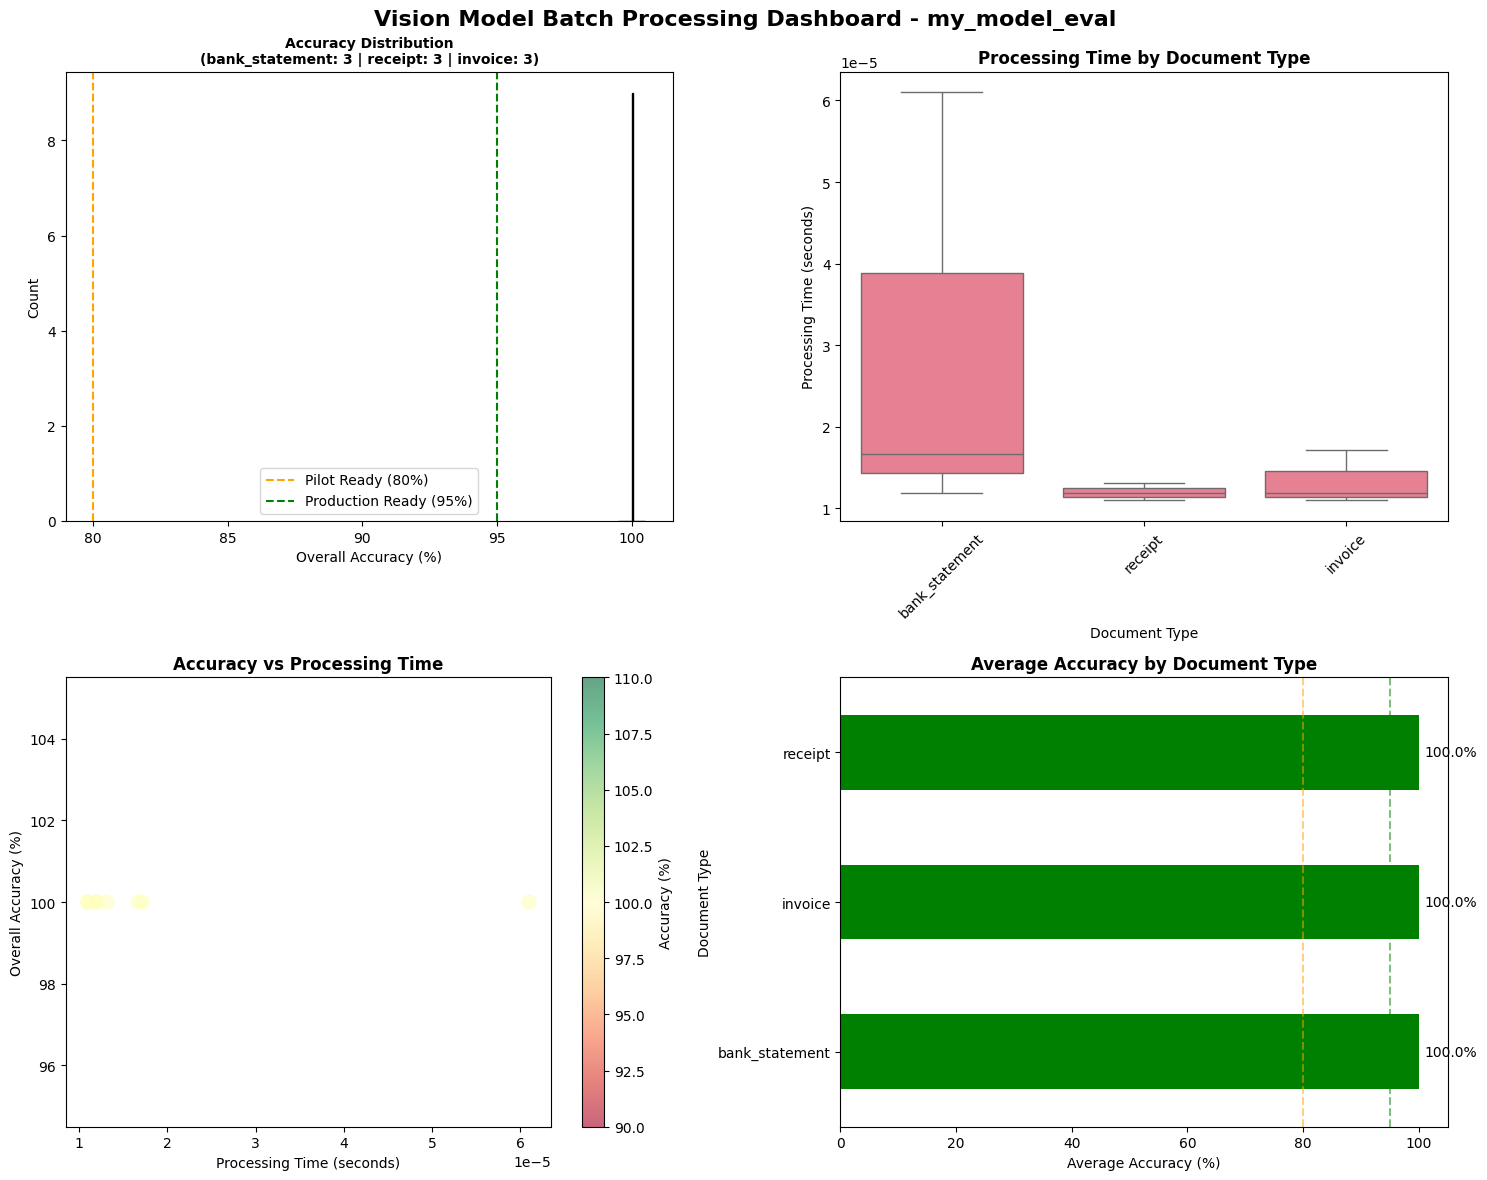

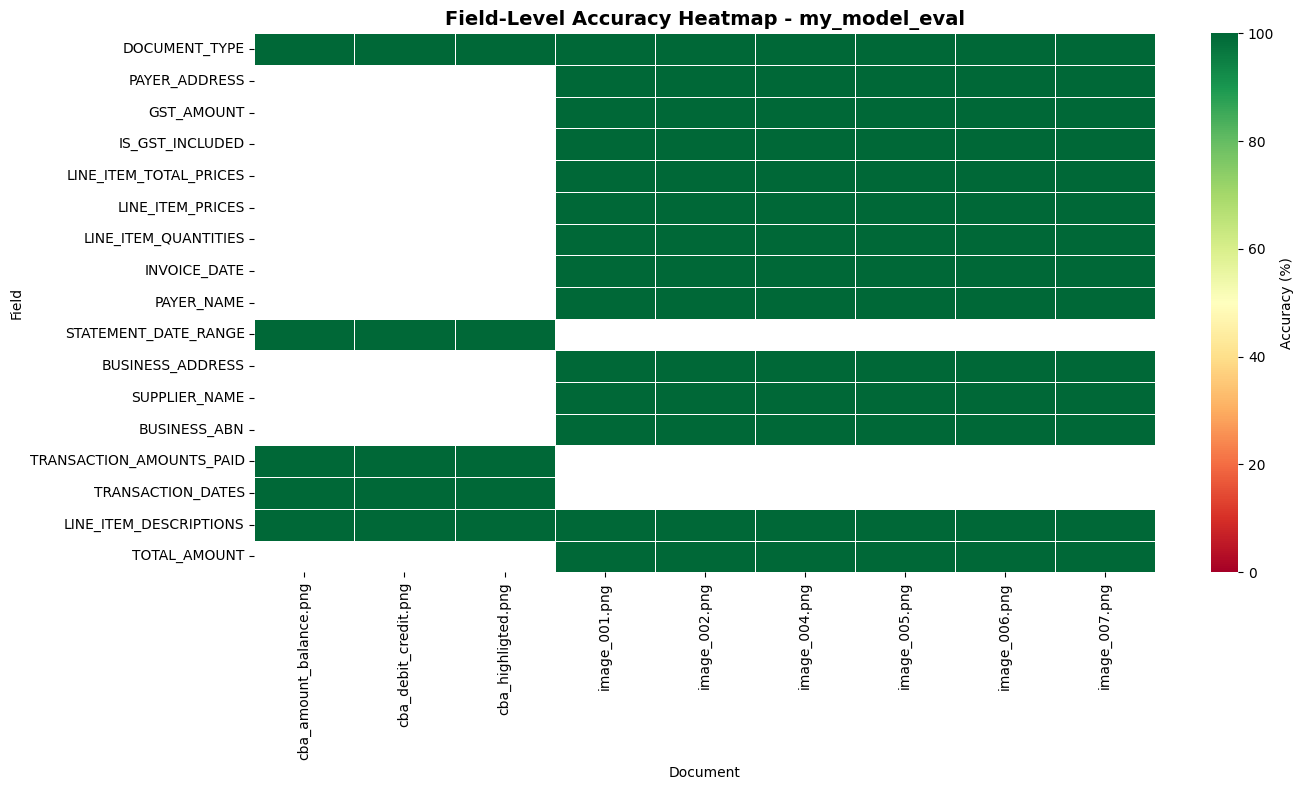

(None,
                           Average Accuracy (%)  Min Accuracy (%)  \
 DOCUMENT_TYPE                            100.0             100.0   
 PAYER_ADDRESS                            100.0             100.0   
 GST_AMOUNT                               100.0             100.0   
 IS_GST_INCLUDED                          100.0             100.0   
 LINE_ITEM_TOTAL_PRICES                   100.0             100.0   
 LINE_ITEM_PRICES                         100.0             100.0   
 LINE_ITEM_QUANTITIES                     100.0             100.0   
 INVOICE_DATE                             100.0             100.0   
 PAYER_NAME                               100.0             100.0   
 STATEMENT_DATE_RANGE                     100.0             100.0   
 BUSINESS_ADDRESS                         100.0             100.0   
 SUPPLIER_NAME                            100.0             100.0   
 BUSINESS_ABN                             100.0             100.0   
 TRANSACTION_AMOUNTS_PAID  

In [8]:
# Cell 8: Visualizations — dashboard charts

visualizer = BatchVisualizer()

# Performance dashboard (2x2 grid)
visualizer.create_dashboard(
    df_results, df_doctype, timestamp,
    save_path=None,  # Set to Path("output/dashboard.png") to save
    show=True,
)

# Field-level accuracy heatmap
visualizer.create_field_heatmap(
    df_results, timestamp,
    save_path=None,  # Set to Path("output/heatmap.png") to save
    show=True,
)